# Lab Project 5: Facebook Posts

Please load `dataset_Facebook.csv`, which contains data about almost 500 posts published on the Facebook page of a renowned cosmetics brand. Specifically, the file includes the following variables:
- `Page_Total_Likes`: Total number of likes of the Facebook page when the post was published
- `Post_Type`: Type of post, i.e. link, photo, status, or video
- `Post_Category`: Content category of the post, i.e. action (special offers and contests), product (explicit brand content), or inspiration (non-explicit brand related content)
- `Post_Weekday`: Weekday when post was published
- `Post_Hour`: Hour when the post was published, i.e. 0-23
- `Post_Paid`: If the brand paid Facebook for the post (True/False)
- `Post_Likes`: Number of likes the post received

Please complete the following tasks to come up with **3 insights**:
1. Conduct an exploratory data analysis using descriptive statistics, counts of unique values, etc.
2. Predict either `Post_Likes` **or** `Post_Paid` using appropriate models and save the predictions of each model as a separate CSV file

Answer the following questions and include your final code below. When you are done, click on `Run` > `Restart Kernel and Run All Cells...` and verify the output.
- Q: Which nominal/ordinal variables did you recode and how?
- A: I recoded post_type, post_category, and post_weekday. The only item I percieved to be ordinal was post_weekday, which was encoded with the replace code. The other two were given the dummy code to drop one item. 
- Q: What is your 1st insight? (Answer in 1-3 sentences.)
- A: The Post_Likes variable is continuous data, leading to complex confusion matrices and low classification performance. Therefore, the matrices were too complex. 
- Q: What is your 2nd insight? (Answer in 1-3 sentences.)
- A: Among regression models, Linear Regression performed best with a Mean Absolute Error of around 72.
- Q: What is your 3rd insight? (Answer in 1-3 sentences.)
- A: Descriptive analysis showed that photo posts and “action” category content were most frequent and likely to receive higher engagement. Posts published on weekends also were more common, showing that timing and content type are important. 

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv('dataset_Facebook.csv')

In [3]:
df

,Page_Total_Likes,Post_Type,Post_Category,Post_Weekday,Post_Hour,Post_Paid,Post_Likes
0,139441,Photo,product,Wednesday,3,False,79.0
1,139441,Status,product,Tuesday,10,False,130.0
2,139441,Photo,inspiration,Tuesday,3,False,66.0
3,139441,Photo,product,Monday,10,True,0.0
4,139441,Photo,product,Monday,3,False,325.0
...,...,...,...,...,...,...,...
488,85093,Photo,inspiration,Saturday,10,False,125.0
489,85093,Photo,inspiration,Saturday,2,False,53.0
490,81370,Photo,product,Thursday,8,False,53.0
491,81370,Photo,action,Thursday,2,False,93.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 493 entries, 0 to 492
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Page_Total_Likes  493 non-null    int64  
 1   Post_Type         493 non-null    object 
 2   Post_Category     493 non-null    object 
 3   Post_Weekday      493 non-null    object 
 4   Post_Hour         493 non-null    int64  
 5   Post_Paid         493 non-null    bool   
 6   Post_Likes        493 non-null    float64
dtypes: bool(1), float64(1), int64(2), object(3)
memory usage: 23.7+ KB


In [5]:
df.describe()


,Page_Total_Likes,Post_Hour,Post_Likes
count,493.000000,493.000000,493.000000
mean,123256.784990,7.888438,116.969574
std,16160.728643,4.371207,98.607588
min,81370.000000,1.000000,0.000000
25%,113028.000000,3.000000,48.000000
50%,129600.000000,9.000000,93.000000
75%,136393.000000,11.000000,162.000000
max,139441.000000,23.000000,485.000000


In [6]:
df['Post_Type'].value_counts()

Post_Type
Photo     419
Status     45
Link       22
Video       7
Name: count, dtype: int64

In [7]:
df['Post_Category'].value_counts()

Post_Category
action         213
inspiration    153
product        127
Name: count, dtype: int64

In [8]:
df['Post_Weekday'].value_counts()

Post_Weekday
Saturday     81
Friday       80
Wednesday    70
Sunday       68
Monday       66
Thursday     65
Tuesday      63
Name: count, dtype: int64

In [9]:
df = pd.get_dummies(df, columns=['Post_Type', 'Post_Category'], drop_first=True)

In [10]:
df

,Page_Total_Likes,Post_Weekday,Post_Hour,Post_Paid,Post_Likes,Post_Type_Photo,Post_Type_Status,Post_Type_Video,Post_Category_inspiration,Post_Category_product
0,139441,Wednesday,3,False,79.0,True,False,False,False,True
1,139441,Tuesday,10,False,130.0,False,True,False,False,True
2,139441,Tuesday,3,False,66.0,True,False,False,True,False
3,139441,Monday,10,True,0.0,True,False,False,False,True
4,139441,Monday,3,False,325.0,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
488,85093,Saturday,10,False,125.0,True,False,False,True,False
489,85093,Saturday,2,False,53.0,True,False,False,True,False
490,81370,Thursday,8,False,53.0,True,False,False,False,True
491,81370,Thursday,2,False,93.0,True,False,False,False,False


In [11]:
df['Post_Weekday'] = df['Post_Weekday'].replace('Sunday', 1, regex=False)
df['Post_Weekday'] = df['Post_Weekday'].replace('Monday', 2, regex=False)
df['Post_Weekday'] = df['Post_Weekday'].replace('Tuesday', 3, regex=False)
df['Post_Weekday'] = df['Post_Weekday'].replace('Wednesday', 4, regex=False)
df['Post_Weekday'] = df['Post_Weekday'].replace('Thursday', 5, regex=False)
df['Post_Weekday'] = df['Post_Weekday'].replace('Friday', 6, regex=False)
df['Post_Weekday'] = df['Post_Weekday'].replace('Saturday', 7, regex=False)

In [12]:
df

,Page_Total_Likes,Post_Weekday,Post_Hour,Post_Paid,Post_Likes,Post_Type_Photo,Post_Type_Status,Post_Type_Video,Post_Category_inspiration,Post_Category_product
0,139441,4,3,False,79.0,True,False,False,False,True
1,139441,3,10,False,130.0,False,True,False,False,True
2,139441,3,3,False,66.0,True,False,False,True,False
3,139441,2,10,True,0.0,True,False,False,False,True
4,139441,2,3,False,325.0,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
488,85093,7,10,False,125.0,True,False,False,True,False
489,85093,7,2,False,53.0,True,False,False,True,False
490,81370,5,8,False,53.0,True,False,False,False,True
491,81370,5,2,False,93.0,True,False,False,False,False


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 493 entries, 0 to 492
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Page_Total_Likes           493 non-null    int64  
 1   Post_Weekday               493 non-null    int64  
 2   Post_Hour                  493 non-null    int64  
 3   Post_Paid                  493 non-null    bool   
 4   Post_Likes                 493 non-null    float64
 5   Post_Type_Photo            493 non-null    bool   
 6   Post_Type_Status           493 non-null    bool   
 7   Post_Type_Video            493 non-null    bool   
 8   Post_Category_inspiration  493 non-null    bool   
 9   Post_Category_product      493 non-null    bool   
dtypes: bool(6), float64(1), int64(3)
memory usage: 18.4 KB


In [14]:
y = df['Post_Likes']

In [15]:
X = df.drop(columns=['Post_Likes'])

In [16]:
X = StandardScaler().fit_transform(X)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [18]:
model = LinearRegression().fit(X_train, y_train)

In [19]:
y_predictions = model.predict(X_test)

In [20]:
mean_absolute_error(y_test, y_predictions)

71.88023335263887

In [21]:
df['Post_Likes'] = model.predict(X)

In [22]:
df

,Page_Total_Likes,Post_Weekday,Post_Hour,Post_Paid,Post_Likes,Post_Type_Photo,Post_Type_Status,Post_Type_Video,Post_Category_inspiration,Post_Category_product
0,139441,4,3,False,113.980852,True,False,False,False,True
1,139441,3,10,False,161.331837,False,True,False,False,True
2,139441,3,3,False,133.735538,True,False,False,True,False
3,139441,2,10,True,130.364994,True,False,False,False,True
4,139441,2,3,False,114.458291,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
488,85093,7,10,False,127.137570,True,False,False,True,False
489,85093,7,2,False,122.010010,True,False,False,True,False
490,81370,5,8,False,106.123237,True,False,False,False,True
491,81370,5,2,False,81.633146,True,False,False,False,False


In [23]:
df.to_csv('out_likes_linearregression.csv', index=False)

In [24]:
model = DecisionTreeRegressor(random_state=1).fit(X_train, y_train)

In [25]:
y_predictions = model.predict(X_test)

In [26]:
mean_absolute_error(y_test, y_predictions)

98.19354838709677

In [27]:
df['Post_Likes'] = model.predict(X)

In [28]:
df

,Page_Total_Likes,Post_Weekday,Post_Hour,Post_Paid,Post_Likes,Post_Type_Photo,Post_Type_Status,Post_Type_Video,Post_Category_inspiration,Post_Category_product
0,139441,4,3,False,79.0,True,False,False,False,True
1,139441,3,10,False,130.0,False,True,False,False,True
2,139441,3,3,False,66.0,True,False,False,True,False
3,139441,2,10,True,0.0,True,False,False,False,True
4,139441,2,3,False,79.0,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
488,85093,7,10,False,125.0,True,False,False,True,False
489,85093,7,2,False,74.0,True,False,False,True,False
490,81370,5,8,False,53.0,True,False,False,False,True
491,81370,5,2,False,93.0,True,False,False,False,False


In [29]:
df.to_csv('out_likes_decisiontree.csv', index=False)

In [30]:
model = KNeighborsRegressor().fit(X_train, y_train)

In [31]:
y_predictions = model.predict(X_test)

In [32]:
mean_absolute_error(y_test, y_predictions)

80.27903225806452

In [33]:
df['Post_Likes'] = model.predict(X)

In [34]:
df

,Page_Total_Likes,Post_Weekday,Post_Hour,Post_Paid,Post_Likes,Post_Type_Photo,Post_Type_Status,Post_Type_Video,Post_Category_inspiration,Post_Category_product
0,139441,4,3,False,138.0,True,False,False,False,True
1,139441,3,10,False,175.2,False,True,False,False,True
2,139441,3,3,False,98.0,True,False,False,True,False
3,139441,2,10,True,38.4,True,False,False,False,True
4,139441,2,3,False,54.0,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
488,85093,7,10,False,123.6,True,False,False,True,False
489,85093,7,2,False,112.6,True,False,False,True,False
490,81370,5,8,False,133.6,True,False,False,False,True
491,81370,5,2,False,96.6,True,False,False,False,False


In [35]:
df.to_csv('out_likes_kneighbors.csv', index=False)

In [36]:
model = LogisticRegression().fit(X_train, y_train)

In [37]:
y_predictions = model.predict(X_test)

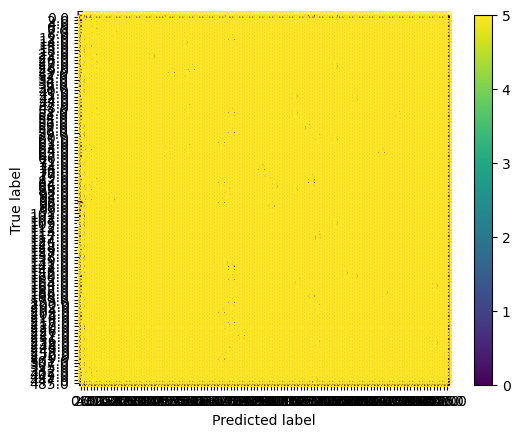

In [38]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predictions)

In [40]:
f1_score(y_test, y_predictions, average='weighted')

0.02563667232597623

In [41]:
df['Post_Likes_Predicted'] = model.predict(X)

In [42]:
df

,Page_Total_Likes,Post_Weekday,Post_Hour,Post_Paid,Post_Likes,Post_Type_Photo,Post_Type_Status,Post_Type_Video,Post_Category_inspiration,Post_Category_product,Post_Likes_Predicted
0,139441,4,3,False,138.0,True,False,False,False,True,0.0
1,139441,3,10,False,175.2,False,True,False,False,True,227.0
2,139441,3,3,False,98.0,True,False,False,True,False,66.0
3,139441,2,10,True,38.4,True,False,False,False,True,0.0
4,139441,2,3,False,54.0,True,False,False,False,True,0.0
...,...,...,...,...,...,...,...,...,...,...,...
488,85093,7,10,False,123.6,True,False,False,True,False,74.0
489,85093,7,2,False,112.6,True,False,False,True,False,74.0
490,81370,5,8,False,133.6,True,False,False,False,True,74.0
491,81370,5,2,False,96.6,True,False,False,False,False,93.0


In [45]:
df.to_csv('out_likes_logisticregression.csv', index=False)

In [46]:
model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)

In [47]:
y_predictions = model.predict(X_test)

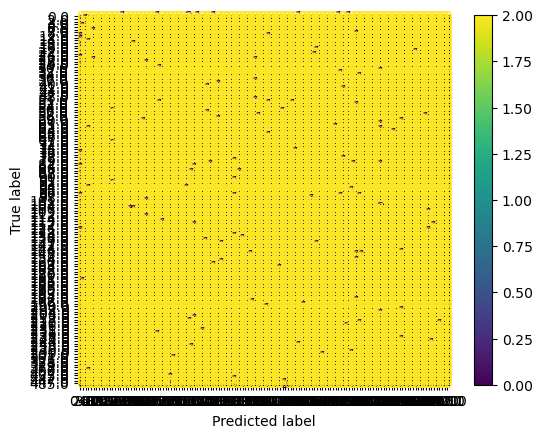

In [48]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predictions)

In [50]:
f1_score(y_test, y_predictions, average='weighted')

0.0

In [51]:
df['Likes_Predicted'] = model.predict(X)

In [52]:
df.to_csv('out_likes_decisiontree.csv', index=False)

In [53]:
model = KNeighborsClassifier().fit(X_train, y_train)

In [54]:
y_predictions = model.predict(X_test)

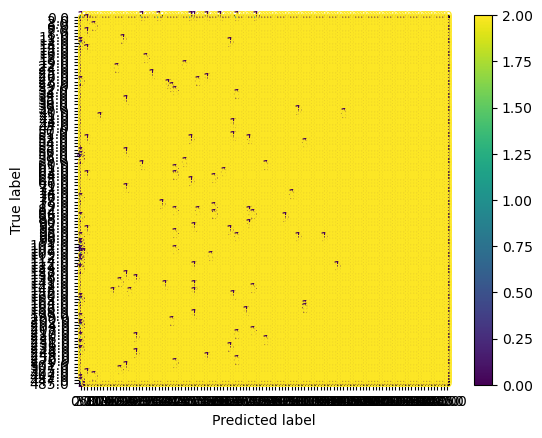

In [55]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predictions)

In [59]:
f1_score(y_test, y_predictions, average = 'weighted')

0.003820033955857385

In [60]:
df['Post_Likes_Predicted'] = model.predict(X)